In [1]:
pip install tensorflow matplotlib

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [3]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
def create_model():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

In [5]:
model_fixed = create_model()

model_fixed.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fixed = model_fixed.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9163 - loss: 0.2802 - val_accuracy: 0.9437 - val_loss: 0.2005
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9485 - loss: 0.1855 - val_accuracy: 0.9419 - val_loss: 0.2203
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9555 - loss: 0.1608 - val_accuracy: 0.9560 - val_loss: 0.1757
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9630 - loss: 0.1374 - val_accuracy: 0.9582 - val_loss: 0.1749
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9648 - loss: 0.1328 - val_accuracy: 0.9523 - val_loss: 0.1908
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9682 - loss: 0.1207 - val_accuracy: 0.9532 - val_loss: 0.1866
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9686 - loss: 0.1176 - val_accuracy: 0.9622 - val_loss: 0.1671
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9709 - loss: 0.1120 - 

In [6]:
model_lr = create_model()

model_lr.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=2,
    verbose=1
)

history_lr = model_lr.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    callbacks=[lr_scheduler],
    verbose=1
)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9149 - loss: 0.2869 - val_accuracy: 0.9442 - val_loss: 0.2092 - learning_rate: 0.0100
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9500 - loss: 0.1804 - val_accuracy: 0.9463 - val_loss: 0.1925 - learning_rate: 0.0100
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.9563 - loss: 0.1595 - val_accuracy: 0.9515 - val_loss: 0.2091 - learning_rate: 0.0100
Epoch 4/15
1495/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9599 - loss: 0.1472
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0009999999776482583.
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9595 - loss: 0.1503 - val_accuracy: 0.9550 - val_loss: 0.1942 - learning_rate: 0.0100
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9784 - loss: 0.0730 - val_accuracy: 0.9718 - val_loss: 0.1144 - learning_rate: 1.0000e-03
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9

In [7]:
model_final = create_model()

model_final.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history_final = model_final.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    callbacks=[lr_scheduler, early_stop],
    verbose=1
)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9203 - loss: 0.2734 - val_accuracy: 0.9408 - val_loss: 0.2058 - learning_rate: 0.0100
Epoch 2/15
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9489 - loss: 0.1809
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0009999999776482583.
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9497 - loss: 0.1827 - val_accuracy: 0.9489 - val_loss: 0.1769 - learning_rate: 0.0100
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9758 - loss: 0.0808 - val_accuracy: 0.9704 - val_loss: 0.1094 - learning_rate: 1.0000e-03
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9824 - loss: 0.0587 - val_accuracy: 0.9723 - val_loss: 0.1013 - learning_rate: 1.0000e-03
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9851 - loss: 0.0468 - val_accuracy: 0.9725 - val_loss: 0.1019 - learning_rate: 1.0000e-03
Epoch 6/15
1495/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy

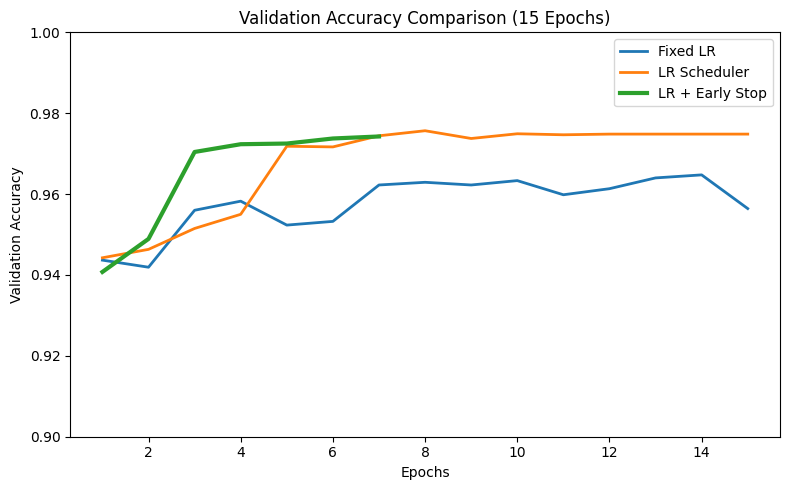

In [8]:
plt.figure(figsize=(8,5))

epochs_fixed = range(1, len(history_fixed.history['val_accuracy'])+1)
epochs_lr = range(1, len(history_lr.history['val_accuracy'])+1)
epochs_final = range(1, len(history_final.history['val_accuracy'])+1)

plt.plot(epochs_fixed, history_fixed.history['val_accuracy'], linewidth=2, label="Fixed LR")
plt.plot(epochs_lr, history_lr.history['val_accuracy'], linewidth=2, label="LR Scheduler")
plt.plot(epochs_final, history_final.history['val_accuracy'], linewidth=3, label="LR + Early Stop")

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison (15 Epochs)")
plt.legend()
plt.ylim(0.90, 1.0)   # zoom for clarity
plt.tight_layout()
plt.show()